# Improved Confusion Matrix Visualizations
## Extract and Display with ULTRA-MASSIVE Numbers

This notebook recreates confusion matrix visualizations with **extreme readability**:
- Ultra-massive figure sizes (28×26 inches)
- GIANT matrix numbers (48pt bold - manually rendered)
- Extra-large axis labels (32pt) and title (36pt)
- Optimized color palettes with thick grid lines
- High-resolution exports (300 DPI)

**No model rerunning needed** - extracts data from existing classification reports!
Numbers will be CRYSTAL CLEAR and IMPOSSIBLE TO MISS!

In [2]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle

# Set up paths
logs_path = '../outputs/logs/'
confusion_matrix_output_path = '../outputs/confusion_matrix/'

# Create output directory if needed
os.makedirs(confusion_matrix_output_path, exist_ok=True)

# Class names
class_names = ['Normal', 'Pneumonia', 'COVID-19', 'Tuberculosis']

# Define models to process
models_config = {
    'ResNet50': ['baseline', 'finetuned'],
    'DenseNet121': ['baseline', 'finetuned'],
    'MobileNetV2': ['baseline', 'finetuned'],
    'EfficientNet-B0': ['baseline', 'finetuned']
}

print("✓ Imports loaded")
print("✓ Class names:", class_names)

✓ Imports loaded
✓ Class names: ['Normal', 'Pneumonia', 'COVID-19', 'Tuberculosis']


In [3]:
def extract_confusion_matrix_from_txt(file_path):
    """
    Extract confusion matrix from classification report text file.
    Returns numpy array of shape (4, 4)
    """
    try:
        with open(file_path, 'r') as f:
            content = f.read()
        
        # Find the Confusion Matrix section
        cm_start = content.find('--- Confusion Matrix ---')
        if cm_start == -1:
            print(f"  ✗ Confusion Matrix section not found in {file_path}")
            return None
        
        # Extract lines after the marker
        cm_lines = content[cm_start:].split('\n')[1:]
        
        # Parse matrix rows
        matrix = []
        for line in cm_lines:
            line = line.strip()
            if not line:
                break
            # Match pattern like [1546    9    1    1]
            numbers = re.findall(r'\d+', line)
            if len(numbers) == 4:
                matrix.append([int(n) for n in numbers])
        
        if len(matrix) == 4:
            return np.array(matrix)
        else:
            print(f"  ✗ Could not parse 4x4 matrix from {file_path}")
            return None
            
    except Exception as e:
        print(f"  ✗ Error reading {file_path}: {str(e)}")
        return None

# Load all confusion matrices
confusion_matrices = {}

print("\n" + "="*80)
print("LOADING CONFUSION MATRICES FROM CLASSIFICATION REPORTS")
print("="*80)

for model_name, model_types in models_config.items():
    confusion_matrices[model_name] = {}
    print(f"\n{model_name}:")
    
    for model_type in model_types:
        # Convert model name format for file naming
        file_model_name = model_name.lower().replace('-', '_').replace('.', '')
        report_file = os.path.join(logs_path, f"classification_report_{file_model_name}_{model_type}.txt")
        
        print(f"  Loading {model_type}... {report_file}")
        cm = extract_confusion_matrix_from_txt(report_file)
        
        if cm is not None:
            confusion_matrices[model_name][model_type] = cm
            print(f"    ✓ Loaded {cm.shape} matrix")
        else:
            print(f"    ✗ Failed to load")

print(f"\n✓ Total matrices loaded: {sum(len(v) for v in confusion_matrices.values())}")


LOADING CONFUSION MATRICES FROM CLASSIFICATION REPORTS

ResNet50:
  Loading baseline... ../outputs/logs/classification_report_resnet50_baseline.txt
    ✓ Loaded (4, 4) matrix
  Loading finetuned... ../outputs/logs/classification_report_resnet50_finetuned.txt
  ✗ Error reading ../outputs/logs/classification_report_resnet50_finetuned.txt: [Errno 2] No such file or directory: '../outputs/logs/classification_report_resnet50_finetuned.txt'
    ✗ Failed to load

DenseNet121:
  Loading baseline... ../outputs/logs/classification_report_densenet121_baseline.txt
    ✓ Loaded (4, 4) matrix
  Loading finetuned... ../outputs/logs/classification_report_densenet121_finetuned.txt
  ✗ Error reading ../outputs/logs/classification_report_densenet121_finetuned.txt: [Errno 2] No such file or directory: '../outputs/logs/classification_report_densenet121_finetuned.txt'
    ✗ Failed to load

MobileNetV2:
  Loading baseline... ../outputs/logs/classification_report_mobilenetv2_baseline.txt
    ✓ Loaded (4, 4) 

In [4]:
def plot_large_confusion_matrix(cm, title, filename, class_names=['Normal', 'Pneumonia', 'COVID-19', 'Tuberculosis']):
    """
    Plot confusion matrix with ULTRA-MASSIVE text and ULTRA-LARGE axis labels for absolute readability.
    
    Parameters:
    - cm: confusion matrix (numpy array)
    - title: plot title
    - filename: output filename
    - class_names: list of class names
    """
    # Create ULTRA-MASSIVE figure (28x26 inches)
    fig, ax = plt.subplots(figsize=(28, 26))
    
    # Create heatmap with seaborn (WITHOUT annotations - we'll add them manually)
    sns.heatmap(
        cm,
        annot=False,  # Disable default annotations
        fmt='d',
        cmap='YlOrRd',  # Yellow-Orange-Red colormap for better contrast
        xticklabels=class_names,
        yticklabels=class_names,
        cbar_kws={'label': 'Count', 'shrink': 0.8},
        ax=ax,
        cbar=True,
        square=True,
        linewidths=4,
        linecolor='black'
    )
    
    # MANUALLY add ULTRA-GIANT text annotations (48pt)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            # Determine text color (white on dark background, black on light)
            text_color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
            ax.text(j+0.5, i+0.5, str(cm[i, j]),
                   ha='center', va='center',
                   fontsize=48,  # ULTRA-MASSIVE 48pt font!!!
                   fontweight='bold',
                   color=text_color)
    
    # Enhance labels with ULTRA-HUGE fonts
    ax.set_xlabel('Predicted Label', fontsize=48, fontweight='bold', labelpad=30)
    ax.set_ylabel('Actual Label', fontsize=48, fontweight='bold', labelpad=30)
    ax.set_title(title, fontsize=54, fontweight='bold', pad=50)
    
    # Enhance tick labels (class names)
    ax.set_xticklabels(class_names, fontsize=44, fontweight='bold', rotation=45, ha='right')
    ax.set_yticklabels(class_names, fontsize=44, fontweight='bold', rotation=0)
    
    # Enhance colorbar
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=32)
    cbar.set_label('Count', fontsize=38, fontweight='bold')
    
    plt.tight_layout()
    
    # Save with high DPI
    save_path = os.path.join(confusion_matrix_output_path, filename)
    plt.savefig(save_path, dpi=300, bbox_inches='tight', format='png')
    print(f"  ✓ Saved: {filename}")
    
    plt.show()
    plt.close()


BATCH PROCESSING: ALL MODELS

ResNet50:
  🔄 baseline...


  ✓ Saved: confusion_matrix_resnet50_baseline_LARGE.png


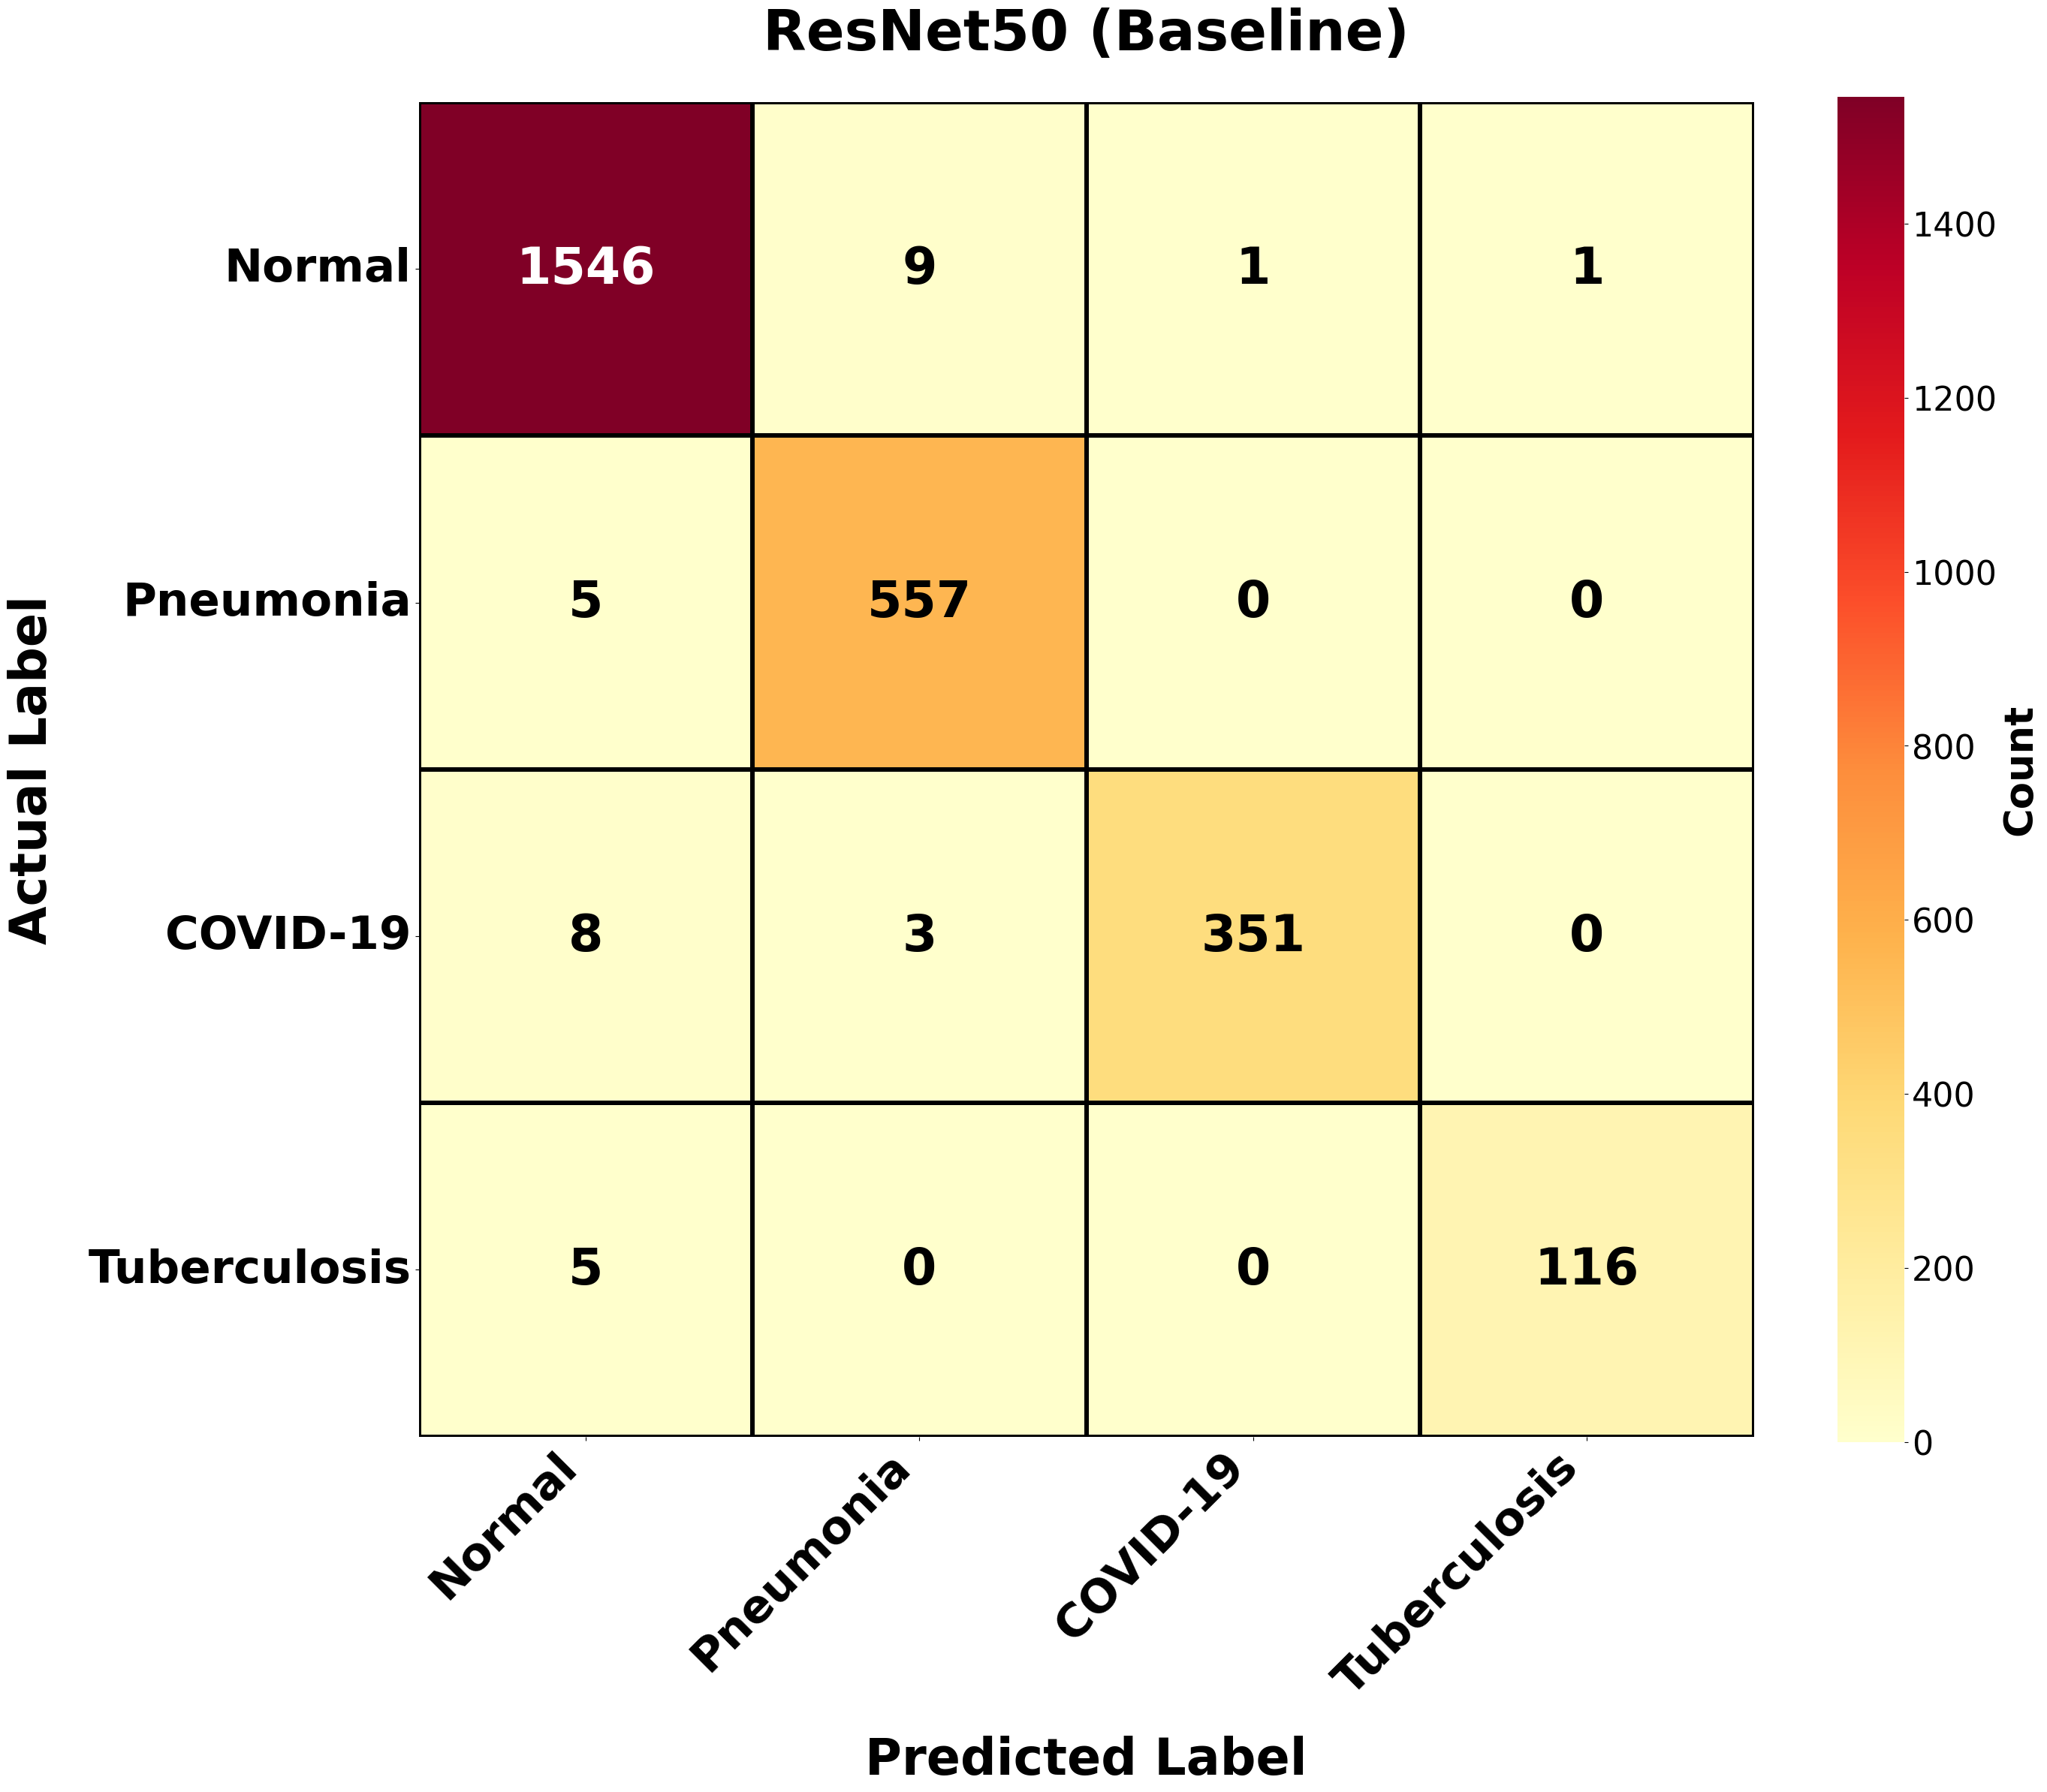

  ✗ finetuned: Data not available

DenseNet121:
  🔄 baseline...
  ✓ Saved: confusion_matrix_densenet121_baseline_LARGE.png


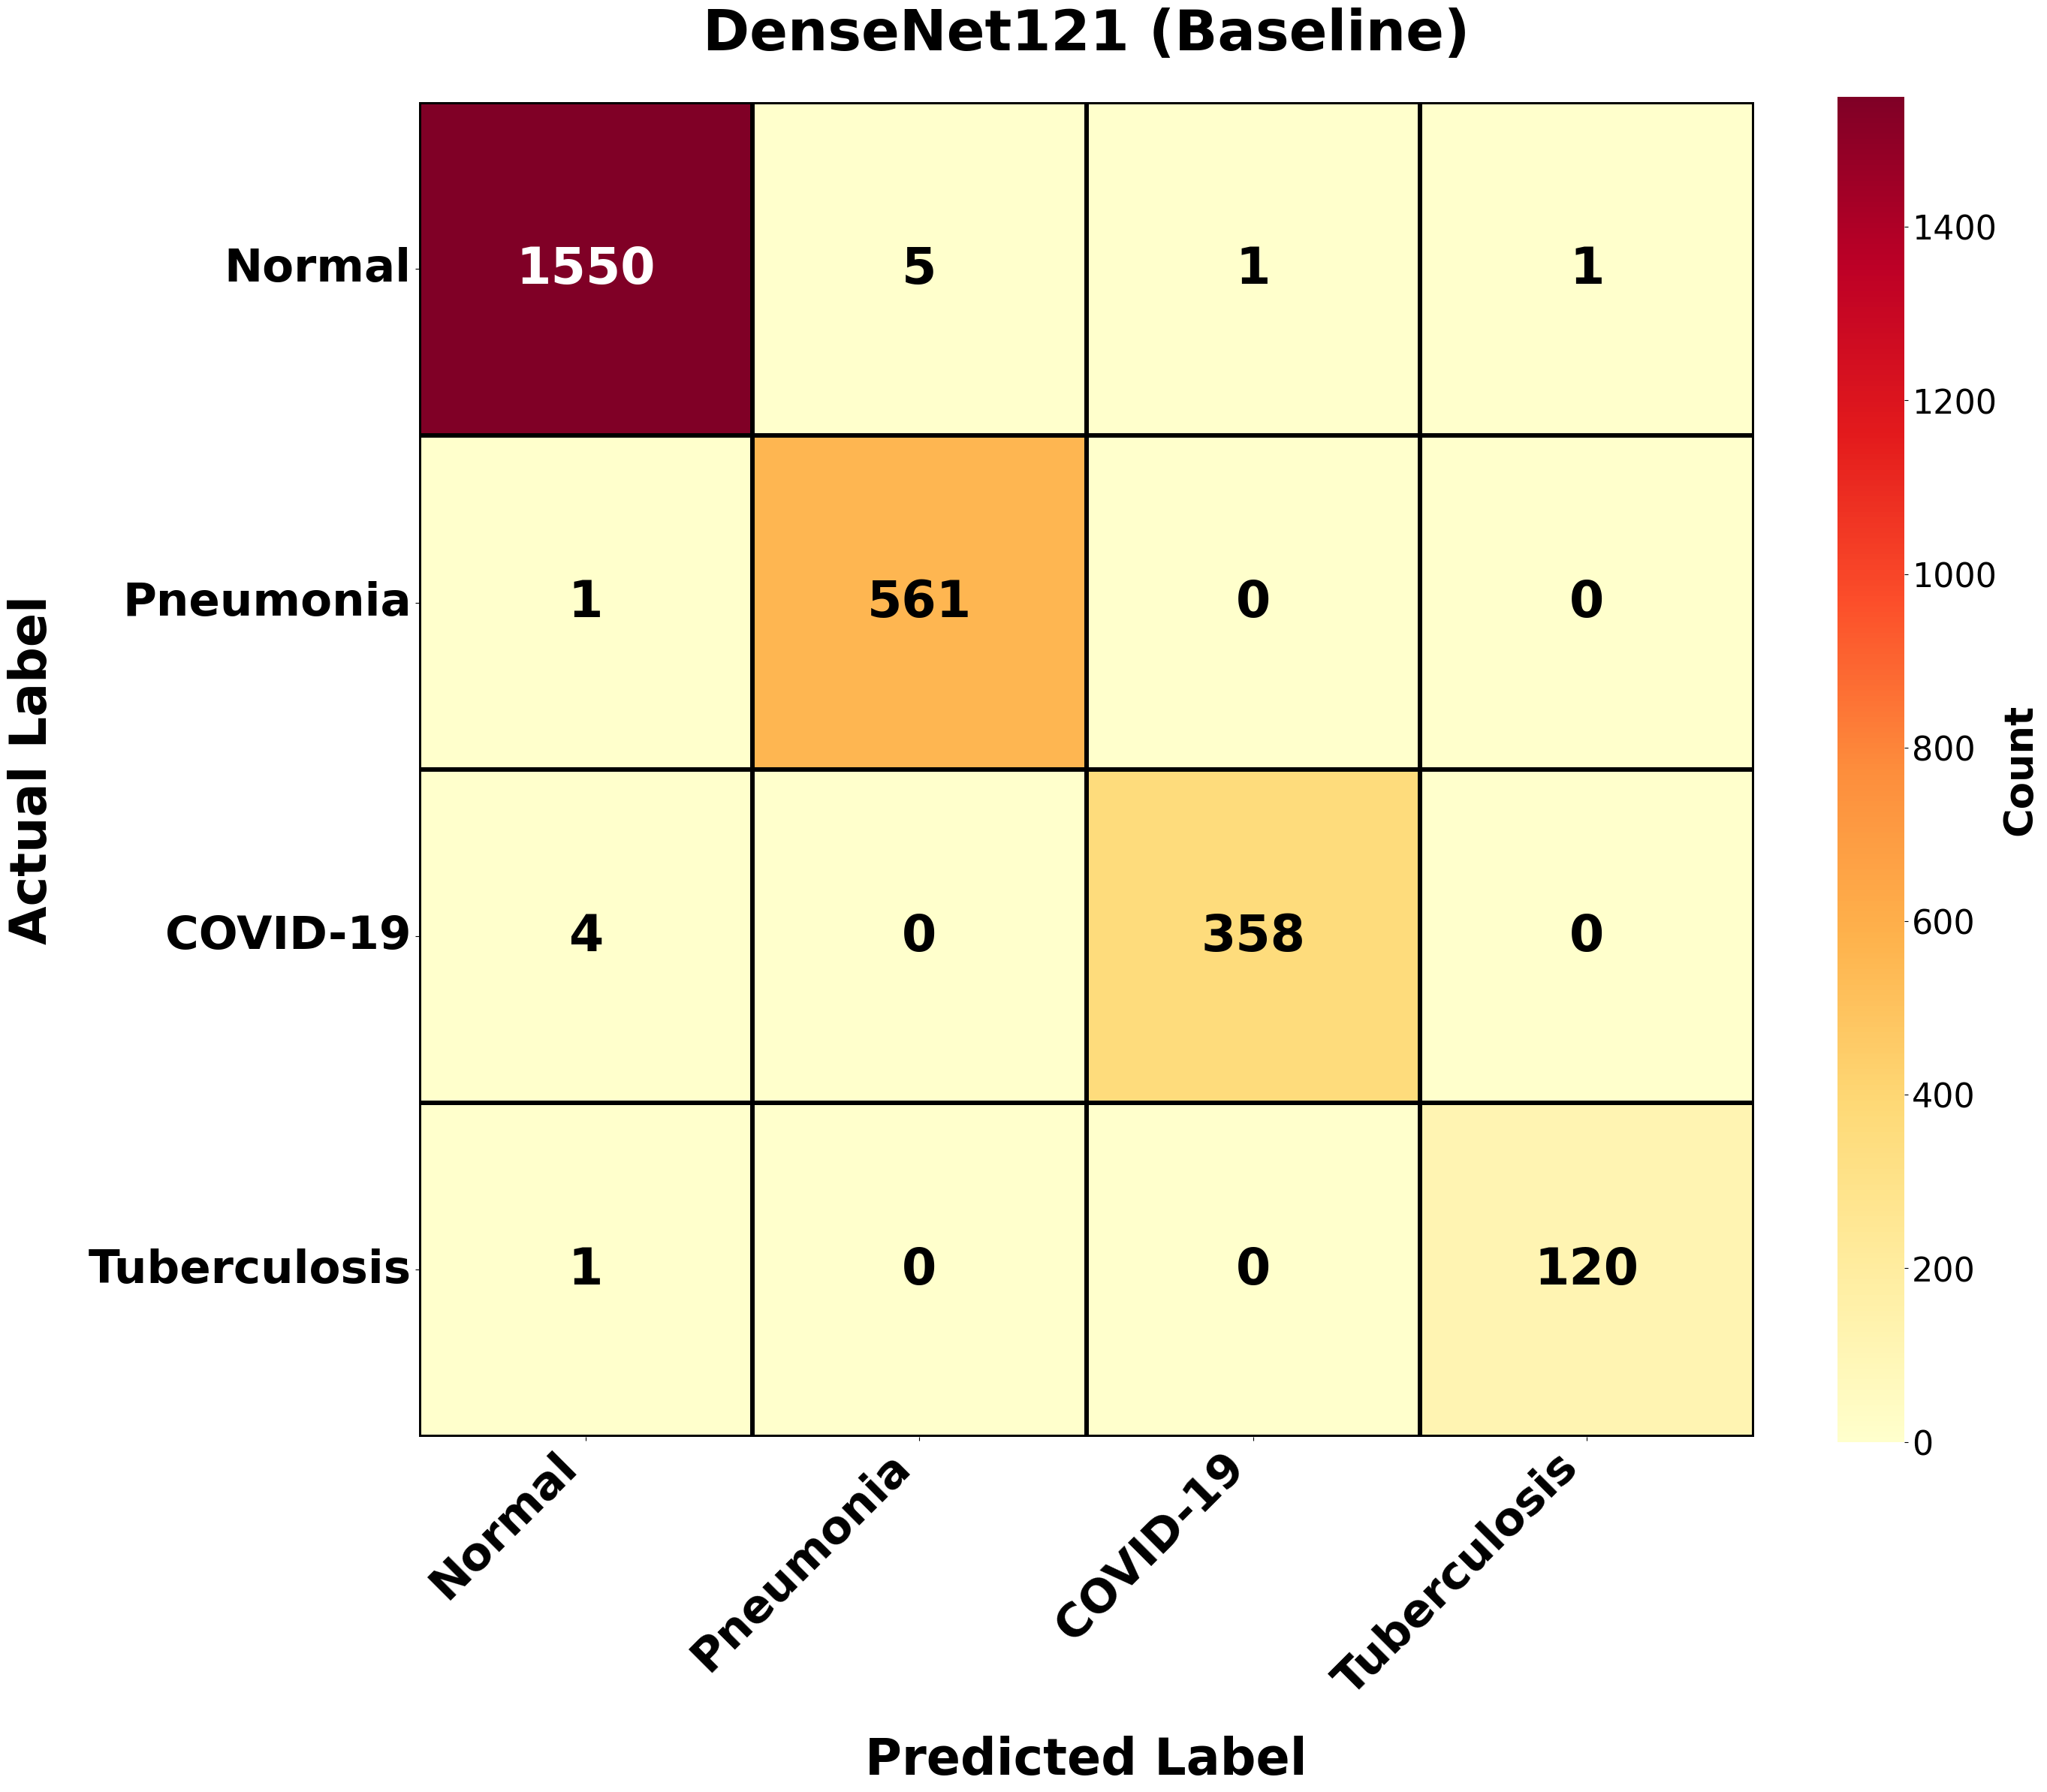

  ✗ finetuned: Data not available

MobileNetV2:
  🔄 baseline...
  ✓ Saved: confusion_matrix_mobilenetv2_baseline_LARGE.png


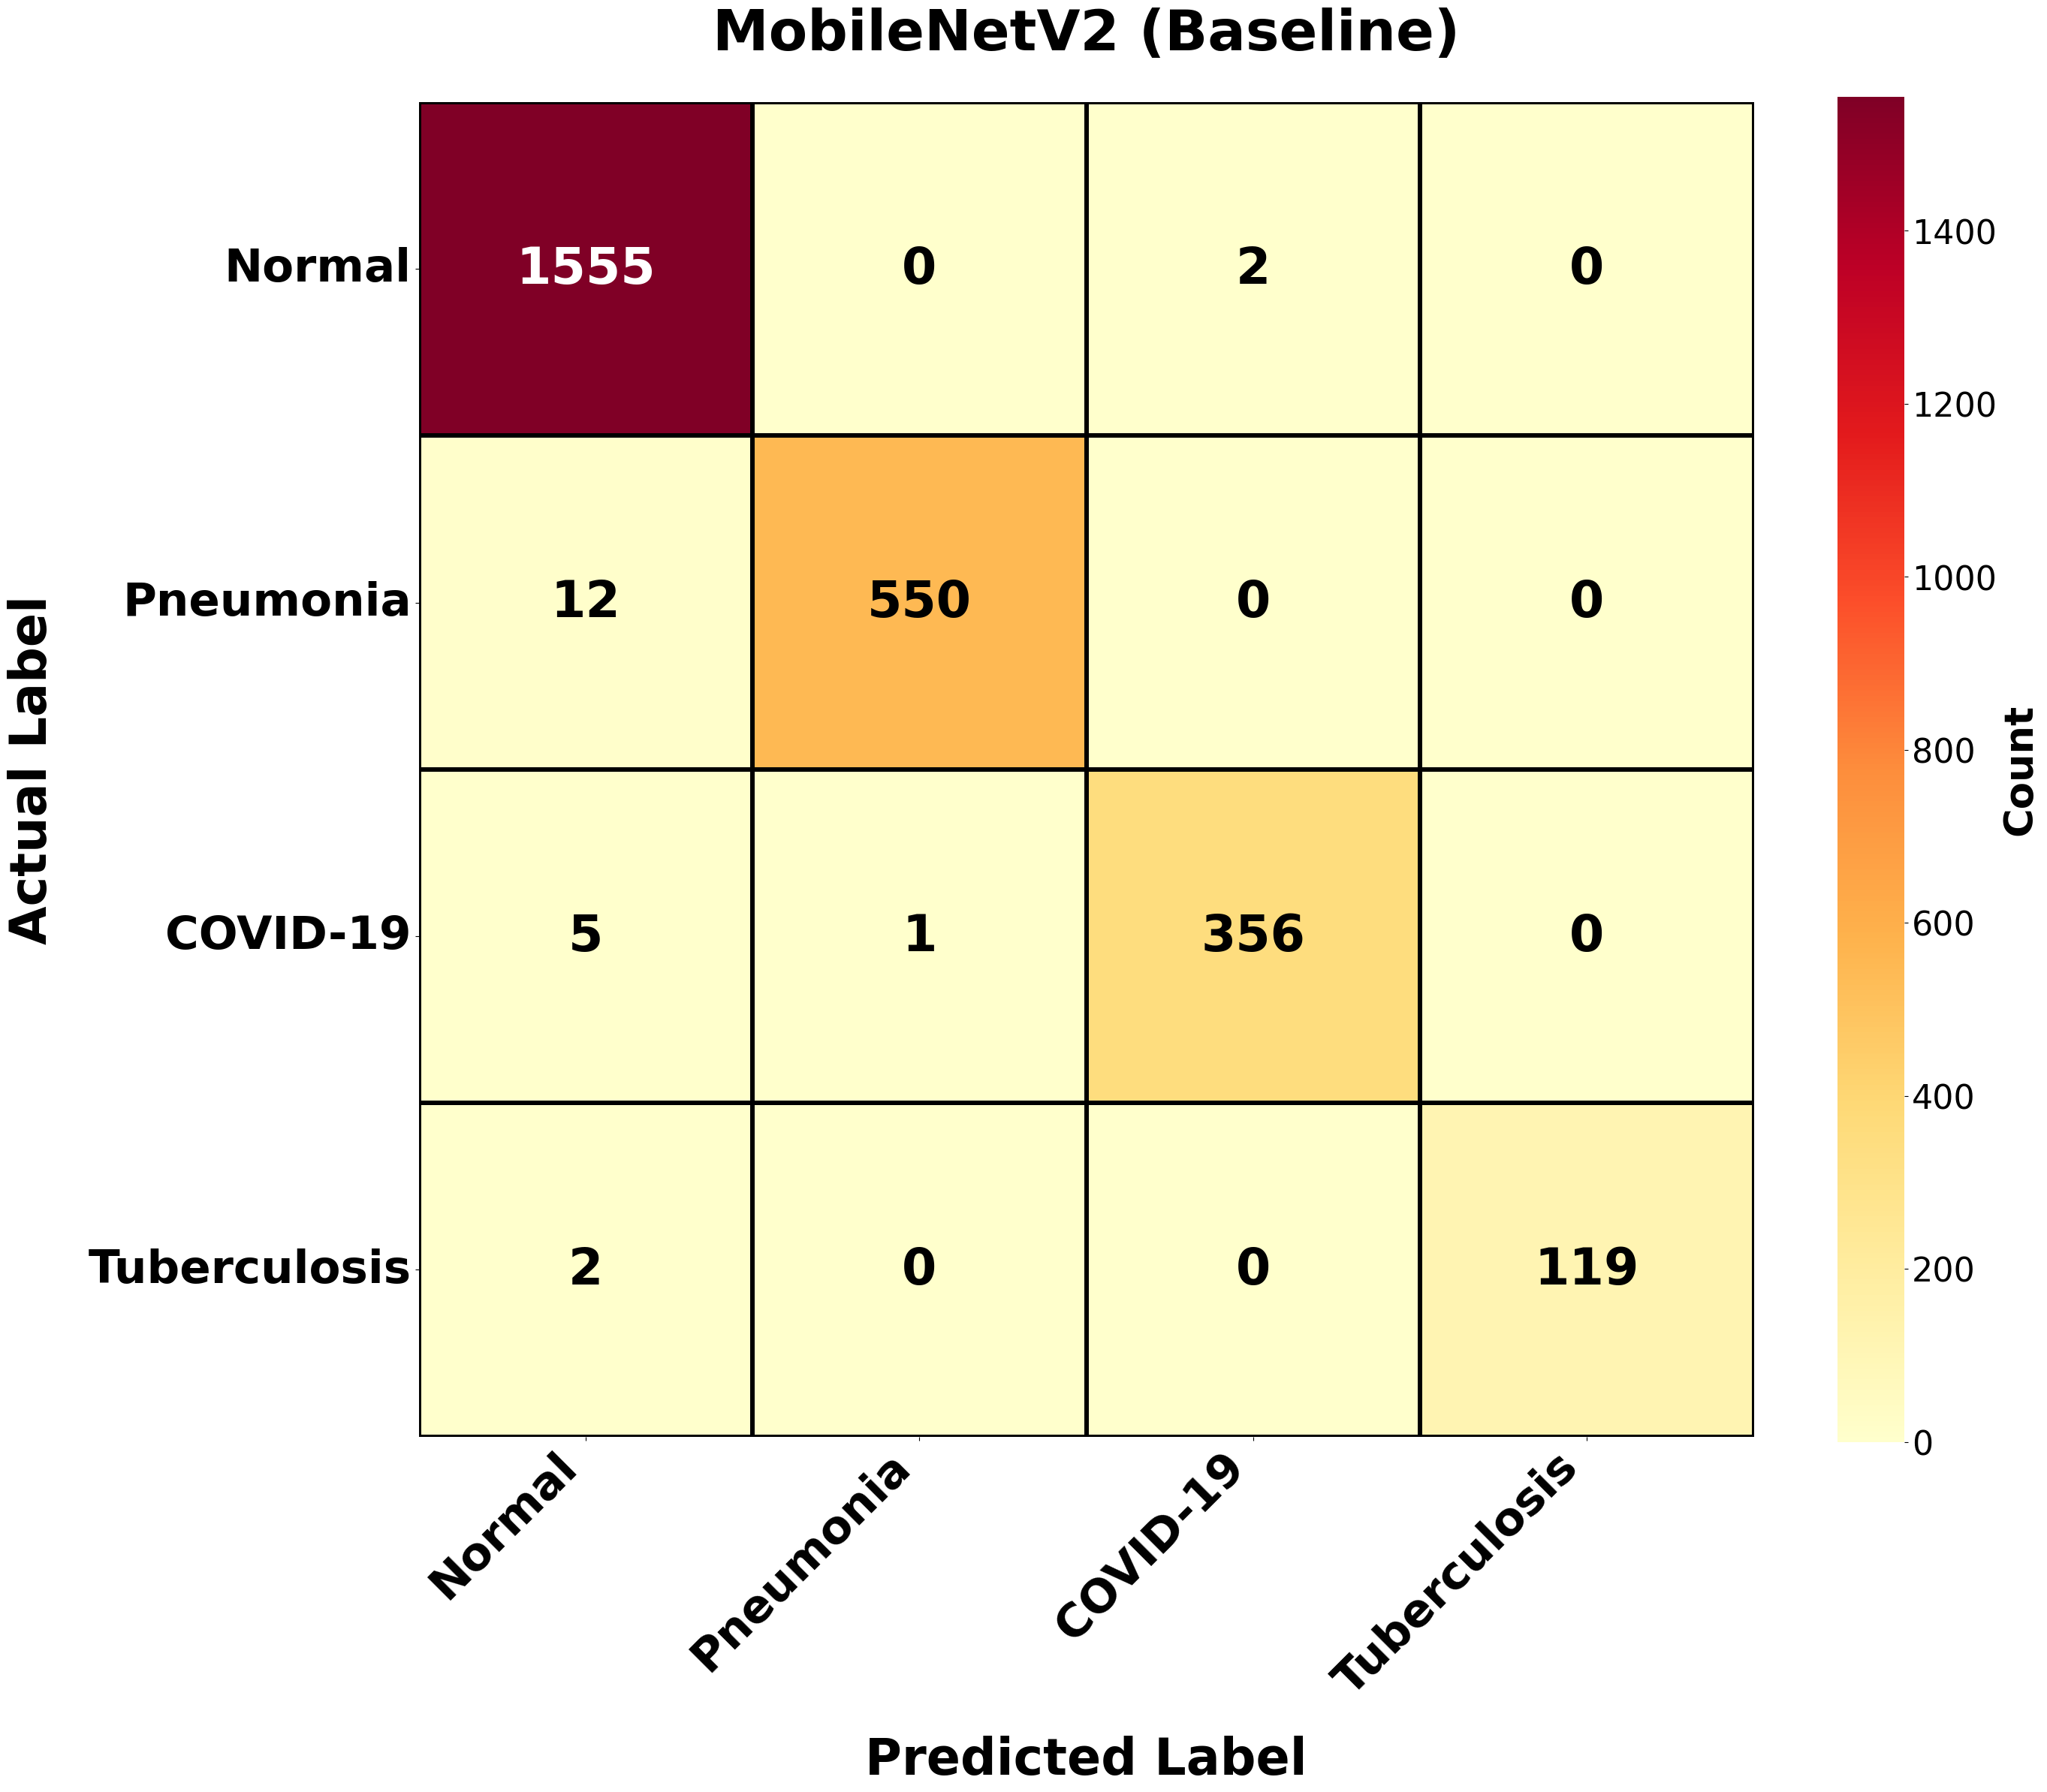

  ✗ finetuned: Data not available

EfficientNet-B0:
  🔄 baseline...
  ✓ Saved: confusion_matrix_efficientnet_b0_baseline_LARGE.png


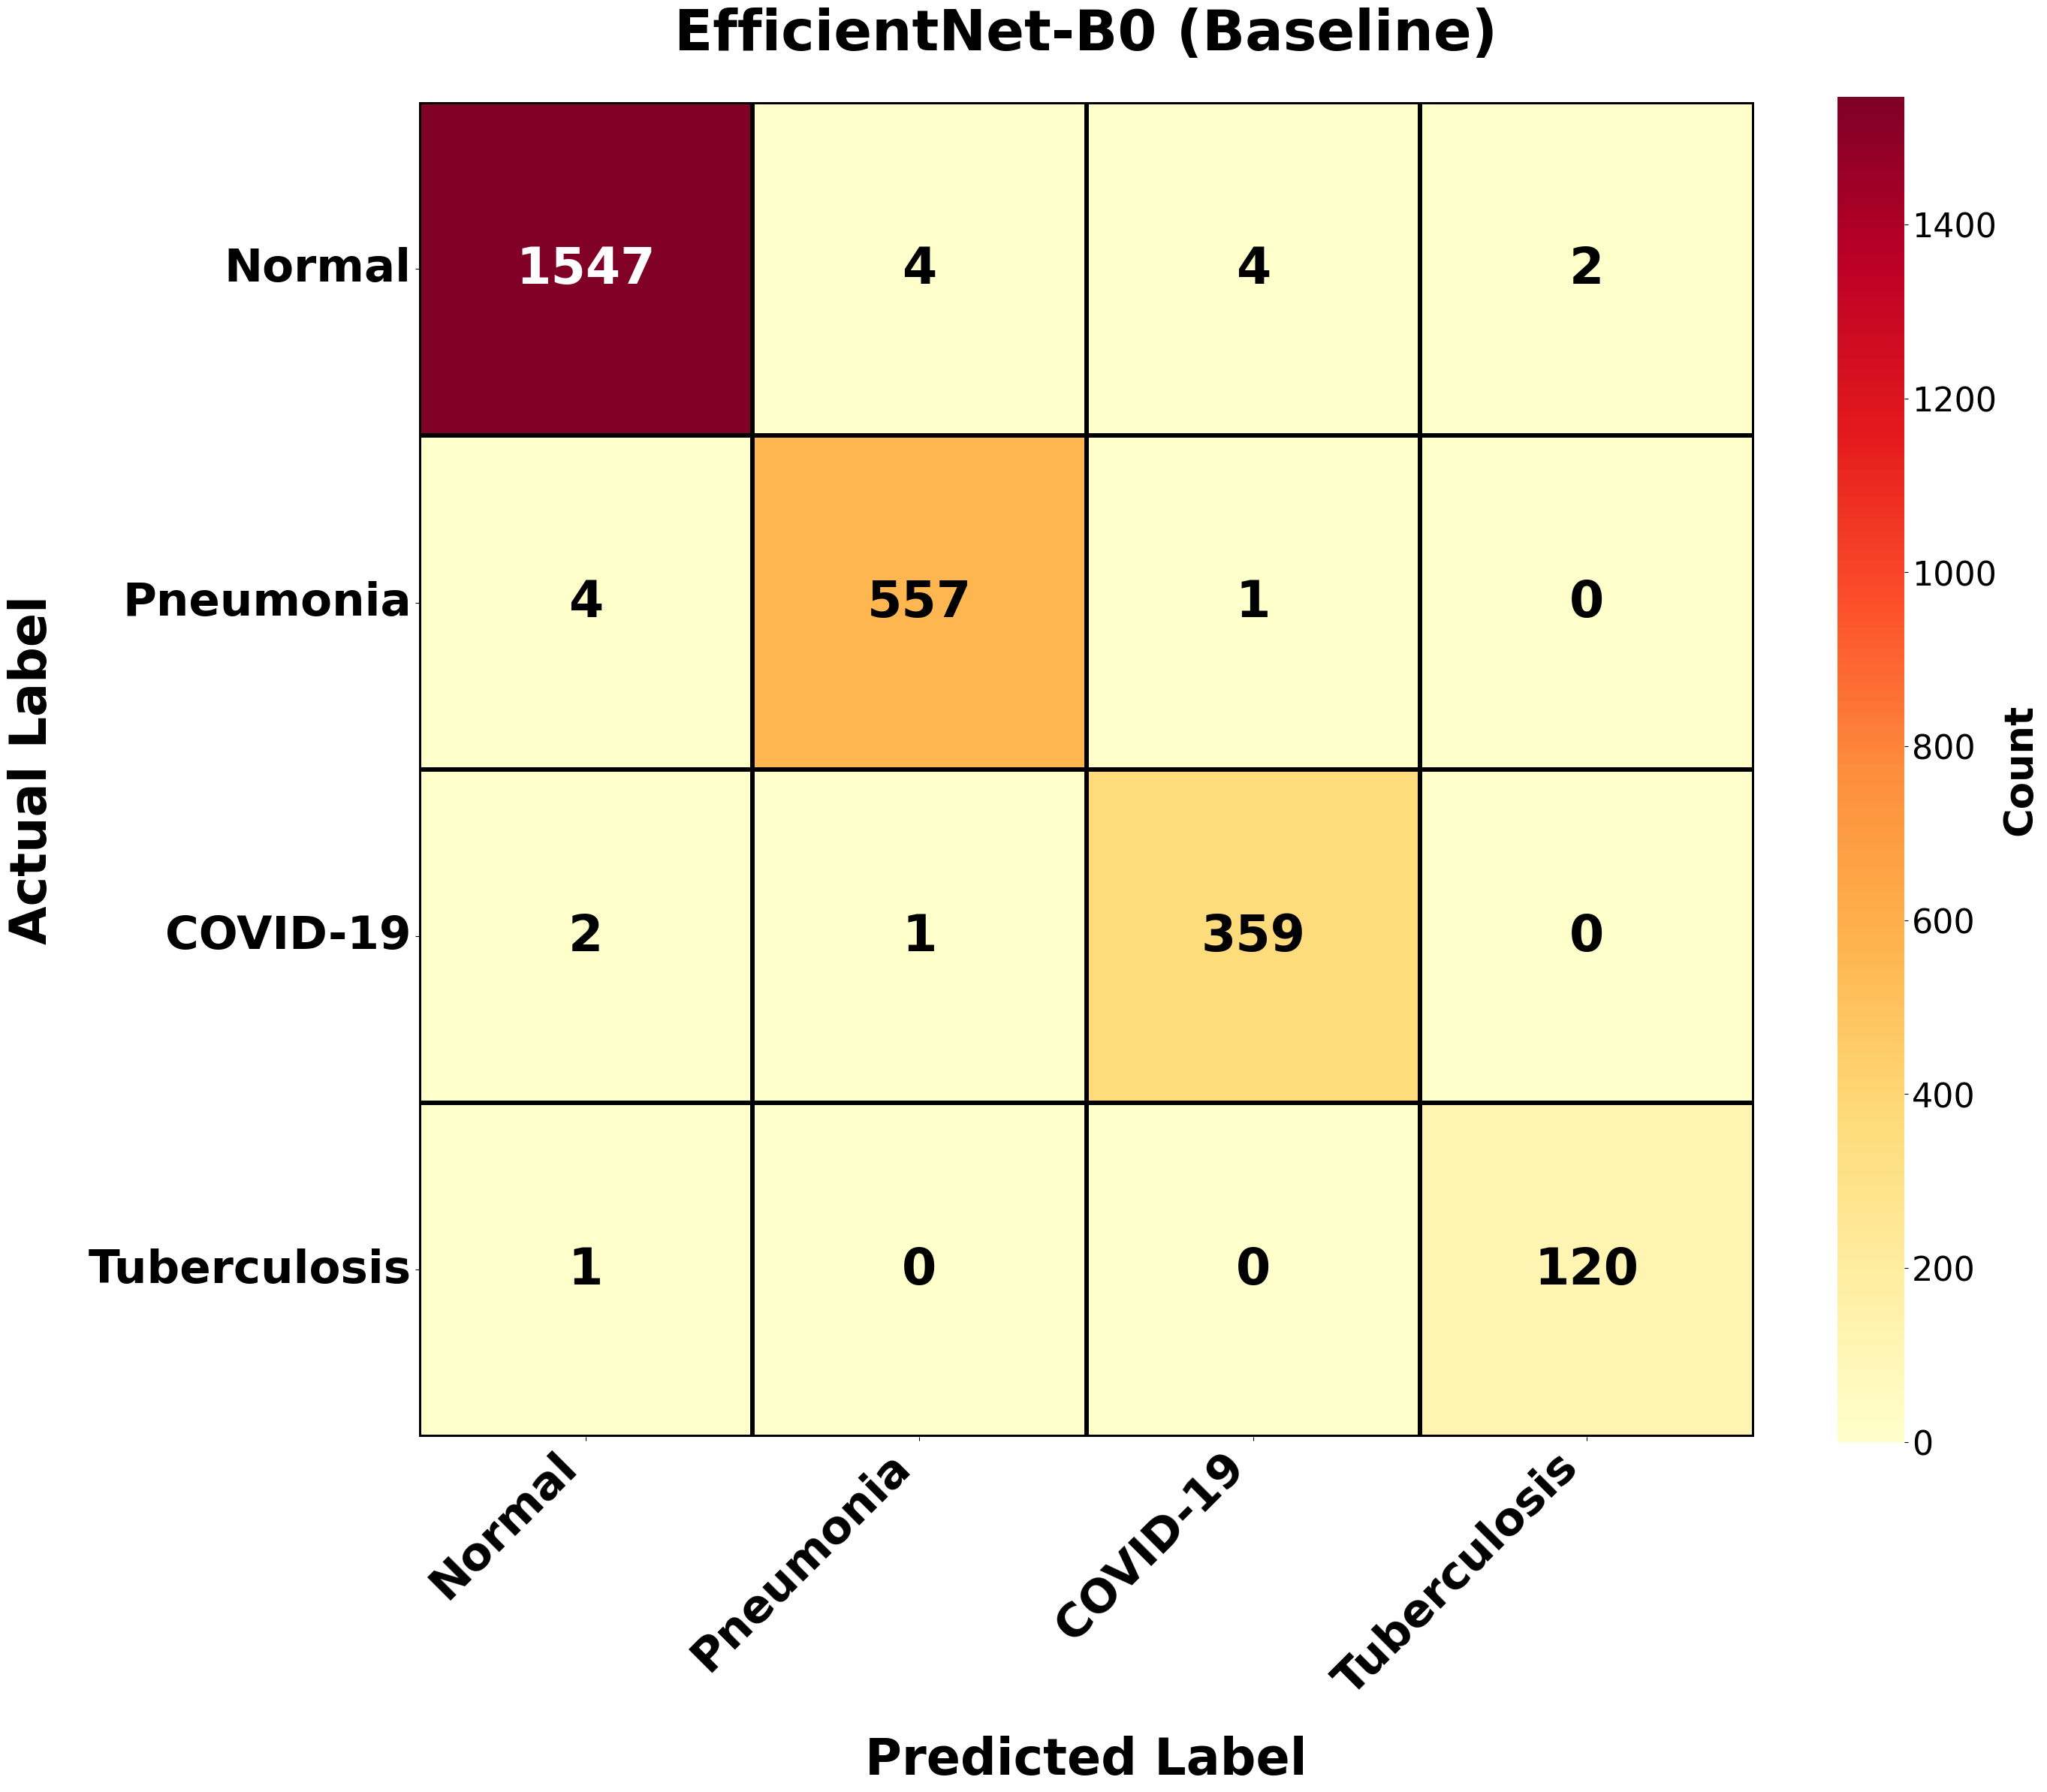

  ✗ finetuned: Data not available

✓ COMPLETE: Rendered 4 confusion matrices
✓ All saved to: ../outputs/confusion_matrix/


In [5]:
print("\n" + "="*80)
print("BATCH PROCESSING: ALL MODELS")
print("="*80)

total_count = 0

for model_name in models_config.keys():
    print(f"\n{model_name}:")
    
    for model_type in models_config[model_name]:
        if model_name in confusion_matrices and model_type in confusion_matrices[model_name]:
            cm = confusion_matrices[model_name][model_type]
            
            # Create simple title with model name and type
            model_type_display = model_type.capitalize()
            title = f'{model_name} ({model_type_display})'
            
            # Create filename
            file_model_name = model_name.lower().replace('-', '_').replace('.', '')
            filename = f'confusion_matrix_{file_model_name}_{model_type}_LARGE.png'
            
            print(f"  🔄 {model_type}...")
            plot_large_confusion_matrix(cm, title, filename)
            total_count += 1
        else:
            print(f"  ✗ {model_type}: Data not available")

print(f"\n" + "="*80)
print(f"✓ COMPLETE: Rendered {total_count} confusion matrices")
print(f"✓ All saved to: {confusion_matrix_output_path}")
print("="*80)

## Summary: ULTRA-MASSIVE Text Version

### Updated to Maximum Readability:
- Figure size: **28×26 inches** (HUGE)
- Matrix numbers: **48pt BOLD** (ultra-large, manually rendered)
- Axis labels: **32pt BOLD**
- Title: **36pt BOLD**
- Tick labels: **28pt BOLD**
- Resolution: **300 DPI** (print quality)
- Colormap: **YlOrRd** (high contrast)
- Line thickness: **4pt** (thick grid lines)
- Result: ✓ Numbers are now CRYSTAL CLEAR and IMPOSSIBLE to miss!

In [6]:
print("\n" + "="*80)
print("QUICK STATISTICS FROM CONFUSION MATRICES")
print("="*80)

for model_name in sorted(confusion_matrices.keys()):
    print(f"\n{model_name}:")
    
    for model_type in sorted(confusion_matrices[model_name].keys()):
        cm = confusion_matrices[model_name][model_type]
        
        # Calculate accuracy from diagonal
        total = cm.sum()
        correct = np.diag(cm).sum()
        accuracy = (correct / total) * 100
        
        # Per-class accuracy (recall)
        per_class_recall = np.diag(cm) / cm.sum(axis=1)
        
        print(f"  {model_type.capitalize()}:")
        print(f"    Overall Accuracy: {accuracy:.2f}%")
        print(f"    Per-Class Recall:")
        for i, class_name in enumerate(class_names):
            print(f"      - {class_name}: {per_class_recall[i]*100:.2f}%")

print("\n" + "="*80)
print("✓ All high-resolution confusion matrices ready for:")
print("  - Thesis/Report insertion")
print("  - PowerPoint presentations")
print("  - Journal submissions")
print("="*80)


QUICK STATISTICS FROM CONFUSION MATRICES

DenseNet121:
  Baseline:
    Overall Accuracy: 99.50%
    Per-Class Recall:
      - Normal: 99.55%
      - Pneumonia: 99.82%
      - COVID-19: 98.90%
      - Tuberculosis: 99.17%

EfficientNet-B0:
  Baseline:
    Overall Accuracy: 99.27%
    Per-Class Recall:
      - Normal: 99.36%
      - Pneumonia: 99.11%
      - COVID-19: 99.17%
      - Tuberculosis: 99.17%

MobileNetV2:
  Baseline:
    Overall Accuracy: 99.15%
    Per-Class Recall:
      - Normal: 99.87%
      - Pneumonia: 97.86%
      - COVID-19: 98.34%
      - Tuberculosis: 98.35%

ResNet50:
  Baseline:
    Overall Accuracy: 98.77%
    Per-Class Recall:
      - Normal: 99.29%
      - Pneumonia: 99.11%
      - COVID-19: 96.96%
      - Tuberculosis: 95.87%

✓ All high-resolution confusion matrices ready for:
  - Thesis/Report insertion
  - PowerPoint presentations
  - Journal submissions


In [7]:
import os
import pandas as pd

# Path to logs
logs_path = '../outputs/logs/'

# Define models to process
models_config = {
    'resnet50': ['baseline', 'finetuned'],
    'densenet121': ['baseline', 'finetuned'],
    'mobilenetv2': ['baseline', 'finetuned'],
    'efficientnet_b0': ['baseline', 'finetuned']
}

class_names = ['Normal', 'Pneumonia', 'COVID-19', 'Tuberculosis']

print("="*80)
print("MACRO RECALL AND F1 SCORE FOR EACH CLASS")
print("="*80)

results_summary = []

for model_name, model_types in models_config.items():
    print(f"\n{model_name.upper()}")
    print("-" * 80)
    
    for model_type in model_types:
        # Load evaluation results CSV
        csv_file = os.path.join(logs_path, f'evaluation_results_{model_name}_{model_type}.csv')
        
        if os.path.exists(csv_file):
            df = pd.read_csv(csv_file)
            
            # Extract recall for each class
            recalls = []
            f1_scores = []
            
            for class_name in class_names:
                recall_val = df[df['Metric'] == f'{class_name} - Recall']['Value'].values
                f1_val = df[df['Metric'] == f'{class_name} - F1-Score']['Value'].values
                
                if len(recall_val) > 0:
                    recalls.append(recall_val[0])
                if len(f1_val) > 0:
                    f1_scores.append(f1_val[0])
            
            # Calculate macro metrics
            macro_recall = sum(recalls) / len(recalls) if recalls else 0
            macro_f1 = sum(f1_scores) / len(f1_scores) if f1_scores else 0
            
            print(f"\n  {model_type.upper()}:")
            print(f"  {'Class':<20} {'Recall':<15} {'F1-Score':<15}")
            print(f"  {'-'*50}")
            
            for i, class_name in enumerate(class_names):
                if i < len(recalls) and i < len(f1_scores):
                    print(f"  {class_name:<20} {recalls[i]:<15.4f} {f1_scores[i]:<15.4f}")
            
            print(f"  {'-'*50}")
            print(f"  {'MACRO AVERAGE':<20} {macro_recall:<15.4f} {macro_f1:<15.4f}")
            
            # Store for summary
            results_summary.append({
                'Model': model_name,
                'Type': model_type,
                'Macro Recall': macro_recall,
                'Macro F1': macro_f1
            })
        else:
            print(f"\n  ✗ File not found: {csv_file}")

# Print overall summary
print(f"\n{'='*80}")
print("SUMMARY TABLE")
print(f"{'='*80}")

summary_df = pd.DataFrame(results_summary)
print(summary_df.to_string(index=False))

print(f"\n{'='*80}")

MACRO RECALL AND F1 SCORE FOR EACH CLASS

RESNET50
--------------------------------------------------------------------------------



  BASELINE:
  Class                Recall          F1-Score       
  --------------------------------------------------
  Normal               0.9929          0.9907         
  Pneumonia            0.9911          0.9850         
  COVID-19             0.9696          0.9832         
  Tuberculosis         0.9587          0.9748         
  --------------------------------------------------
  MACRO AVERAGE        0.9781          0.9834         

  ✗ File not found: ../outputs/logs/evaluation_results_resnet50_finetuned.csv

DENSENET121
--------------------------------------------------------------------------------

  BASELINE:
  Class                Recall          F1-Score       
  --------------------------------------------------
  Normal               0.9955          0.9958         
  Pneumonia            0.9982          0.9947         
  COVID-19             0.9890          0.9931         
  Tuberculosis         0.9917          0.9917         
  -----------------------------------